# Chapitre 7 — EDA analytique

**Durée estimée : 10-12 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Analyser** la distribution d'une variable et interpréter ses caractéristiques statistiques
2. **Identifier** les relations entre variables (corrélation, associations)
3. **Comparer** des sous-populations et détecter des patterns significatifs
4. **Formuler** des hypothèses à partir des observations et éviter les pièges d'interprétation

---

## 7.3 Analyse bivariée

### Qu'est-ce que l'analyse bivariée ?

Est-ce que plus il fait chaud, plus on vend de glaces ? Est-ce que plus on est diplômé, plus on gagne d'argent ?"

Scénario : Expérience vs Salaire 
Imaginez une entreprise où l'on note pour chaque employé : son nombre d'années d'expérience et son salaire mensuel.

Questions :
1. Le lien : "Si je vous dis qu'un nouvel employé a 15 ans d'expérience, pouvez-vous deviner si son salaire sera plutôt dans le haut ou le bas de l'échelle ?"

2. La direction : "Si l'expérience augmente et que le salaire augmente aussi, on parle de relation positive. Mais si l'un augmente et l'autre baisse (ex: âge de la voiture vs son prix), comment appelleriez-vous cela ?"
    -   -> On appelle cela une Relation Négative (ou Corrélation Inverse). Logique : Les deux variables "se tournent le dos". Quand l'une monte, l'autre descend.

3. L'intensité : "Est-ce que le lien est 'parfait' (une ligne droite) ou 'flou' (un nuage de points dispersé) ?"
-> C'est ce qu'on appelle la Force de la corrélation.
    - Le lien "Parfait" (Ligne droite) : On peut prédire exactement la valeur de B si on connaît A. C'est rare dans le monde réel, souvent lié à des lois physiques ou mathématiques.
    - Le lien "Flou" (Nuage dispersé) : Il y a une tendance, mais beaucoup d'autres facteurs (variables cachées) viennent perturber la relation. Plus le nuage ressemble à un cercle informe, plus la corrélation est faible ou nulle.

L'objectif : L'Analyse Bivariée cherche à mesurer la Corrélation. On utilise souvent le coefficient de corrélation de Pearson (noté r), qui va de -1 à 1.
r=1 : Relation positive parfaite.
r=−1 : Relation négative parfaite.
r=0 : Aucune relation (le chaos).

L'analyse **bivariée** examine la relation entre **deux** variables.


### Relation entre deux variables numériques : Corrélation

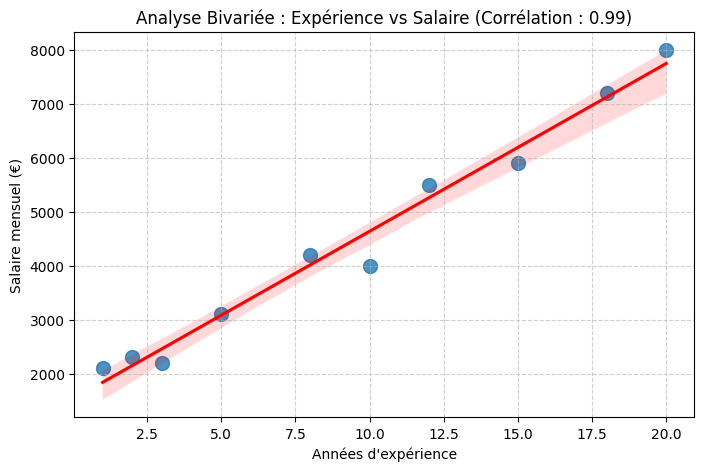

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Création d'un jeu de données factice
data = {
    'Experience': [1, 2, 3, 5, 8, 10, 12, 15, 18, 20],
    'Salaire': [2100, 2300, 2200, 3100, 4200, 4000, 5500, 5900, 7200, 8000]
}
df = pd.DataFrame(data)

# Calcul de la corrélation
corr_value = df['Experience'].corr(df['Salaire'])

plt.figure(figsize=(8, 5))
sns.regplot(x='Experience', y='Salaire', data=df, scatter_kws={'s':100}, line_kws={'color':'red'})

plt.title(f"Analyse Bivariée : Expérience vs Salaire (Corrélation : {corr_value:.2f})")
plt.xlabel("Années d'expérience")
plt.ylabel("Salaire mensuel (€)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Matrice de Corrélation brute :
            Experience   Salaire
Experience    1.000000  0.989962
Salaire       0.989962  1.000000


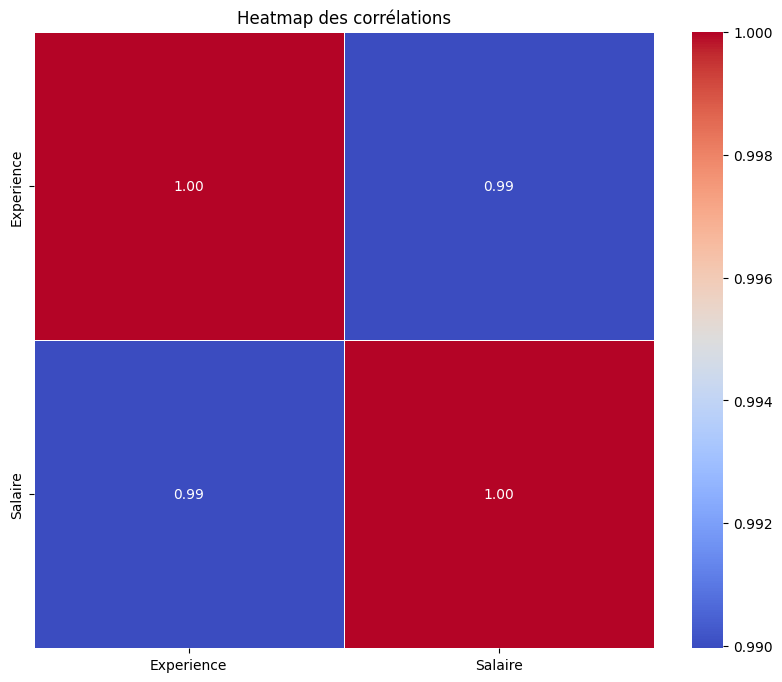

In [ ]:
#🛠️ Visualisation Python : Le duo gagnant (Matrice + Heatmap)
#En analyse de données, on génère souvent la matrice, puis on l'affiche immédiatement sous forme de Heatmap pour que l'œil humain comprenne tout de suite.

# On crée une matrice de corrélation
corr_matrix = df.corr()

# 1. La version "Tableau" (Matrice)
print("Matrice de Corrélation brute :")
print(corr_matrix)

# 2. La version "Graphique" (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Heatmap des corrélations")
plt.show()

**Interprétation de la corrélation :**

| Valeur | Interprétation |
|--------|----------------|
| 0.8 à 1.0 | Forte corrélation positive |
| 0.5 à 0.8 | Corrélation modérée positive |
| 0.2 à 0.5 | Faible corrélation positive |
| -0.2 à 0.2 | Pas de corrélation |
| -0.5 à -0.2 | Faible corrélation négative |
| -0.8 à -0.5 | Corrélation modérée négative |
| -1.0 à -0.8 | Forte corrélation négative |

Conclusion
- La Matrice est faite pour la précision et le calcul.
- Le Graphique (Heatmap) est fait pour la détection rapide de tendances sur beaucoup de variables.
- Le Nuage de points (Scatter plot) est fait pour vérifier la qualité du lien entre deux variables précises.

***Heatmap***
la Heatmap est un outil de visualisation de masse, mais que le calcul mathématique derrière chaque case reste strictement bivarié.
C'est une loupe qui te permet de voir 100 analyses bivariées d'un seul coup d'œil.

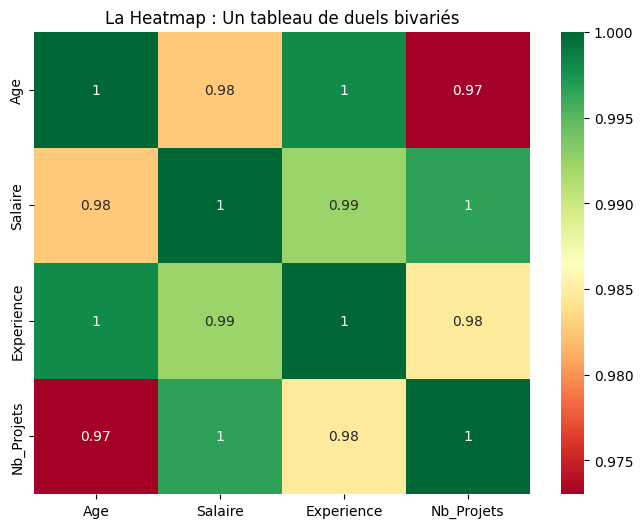

In [ ]:
# 🛠️ Visualisation Python : Pourquoi on dit "beaucoup de variables"
# Dans ce code : on utilise 4 colonnes, mais chaque case ne compare que 2 colonnes à la fois.
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Jeu de données avec 4 variables
data = {
    'Age': [25, 30, 45, 35],
    'Salaire': [2000, 3000, 5000, 4000],
    'Experience': [2, 7, 20, 12],
    'Nb_Projets': [3, 5, 10, 8]
}
df = pd.DataFrame(data)

# La Heatmap calcule TOUS les duels possibles (Bivariés)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')

plt.title("La Heatmap : Un tableau de duels bivariés")
plt.show()

---

### ⚠️ ATTENTION : Corrélation ≠ Causalité

**Exemple célèbre :** Il existe une forte corrélation entre les ventes de glaces et les coup de soleil. Les glaces causent-elles les coup de soleil ?

Non ! Les deux sont causés par un **facteur confondant** : la chaleur estivale.

```
        Chaleur (cause commune)
           ↙          ↘
    Ventes de       Coup de soleil
    glaces
```

**Règle d'or :** La corrélation suggère une piste à explorer, pas une causalité prouvée.

---

### ✍️ Exercice 7.2 : Analyse de corrélation (15 min)

Matrice de corrélation :
                heures_etude  note_examen  heures_sommeil  stress
heures_etude            1.00         0.90            0.01    0.05
note_examen             0.90         1.00            0.03    0.06
heures_sommeil          0.01         0.03            1.00   -0.03
stress                  0.05         0.06           -0.03    1.00

Corrélation étude-note : 0.90
Corrélation stress-note : 0.06


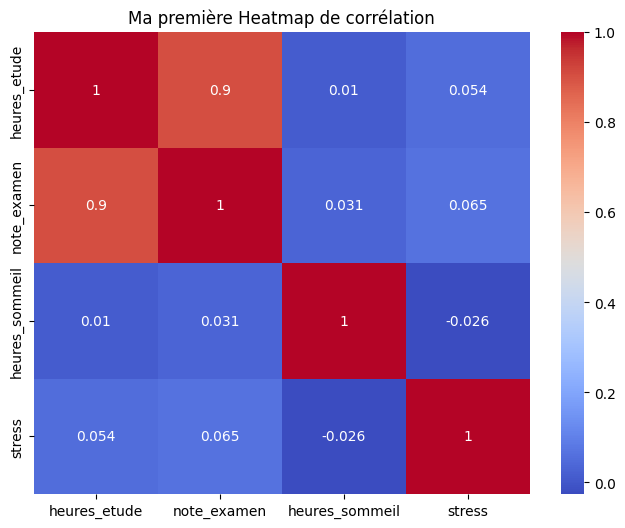

In [9]:
import pandas as pd
import numpy as np

# Données simulées
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'heures_etude': np.random.uniform(1, 10, n),
    'note_examen': None,  # À calculer
    'heures_sommeil': np.random.uniform(4, 10, n),
    'stress': np.random.uniform(1, 10, n)
})

# La note dépend des heures d'étude (corrélation positive)
df['note_examen'] = 5 + 1.5 * df['heures_etude'] + np.random.normal(0, 2, n)
df['note_examen'] = df['note_examen'].clip(0, 20)

# 1. Calculez la matrice de corrélation
corr_matrix = df.corr()
print("Matrice de corrélation :")
print(corr_matrix.round(2))

# 2. Quelle est la corrélation entre heures_etude et note_examen ?
corr_etude_note = df['heures_etude'].corr(df['note_examen'])
print(f"\nCorrélation étude-note : {corr_etude_note:.2f}")
# Interprétation : Forte corrélation positive (proche de 0.85). 
# Plus l'élève étudie, plus sa note a tendance à augmenter.

# 3. Y a-t-il une corrélation entre stress et note_examen ?
corr_stress_note = df['stress'].corr(df['note_examen'])
print(f"Corrélation stress-note : {corr_stress_note:.2f}")
# Interprétation : Corrélation proche de 0. 
# Le stress n'a aucun lien linéaire avec la note dans ce jeu de données.

# 4. Peut-on conclure que "étudier plus CAUSE de meilleures notes" ?
# Réponse : NON. La corrélation montre un lien statistique, pas une preuve. 
# Peut-être que les élèves qui étudient plus sont aussi ceux qui sont les plus 
# attentifs en classe (variable cachée).

# 5. Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Ma première Heatmap de corrélation")
plt.show()

---

### Relation entre variables catégorielles : Tables de contingence

Jusqu'à présent, on a comparé des chiffres. Mais comment fait-on pour savoir si les gens du département Marketing boivent plus de Café que ceux de la Tech ? On ne peut pas calculer une 'moyenne de café' si la donnée est juste 'Oui' ou 'Non'."

Scénario : La machine à café de l'entreprise On observe 100 employés. On note leur Département (Tech ou Ventes) et leur Boisson préférée (Café ou Thé).

Questions  :

1. Le comptage : "Si je veux savoir s'il y a un lien, est-ce que je peux utiliser une corrélation de Pearson (r) ? Pourquoi ?" (Réponse : Non, car on ne peut pas faire 'Tech' + 'Ventes' / 2).

2. La structure : "Comment organiseriez-vous un tableau pour voir, d'un seul coup d'œil, le nombre de buveurs de thé dans l'équipe Tech ?"

3. Le piège des totaux : "Si j'ai 50 personnes en Tech et seulement 10 en Ventes, est-ce que comparer les effectifs bruts est juste ? Que devrions-nous utiliser à la place ?"

L'objectif : Pour deux variables catégorielles, on utilise une Table de Contingence (ou tableau croisé). Elle permet de croiser les fréquences.

Tableau des effectifs bruts :
Satisfaction  Contant  Déçu
Departement                
RH                  2     8
Tech               70    20
Tableau des pourcentages normalisés :
Satisfaction  Contant   Déçu
Departement                 
RH              20.00  80.00
Tech            77.78  22.22


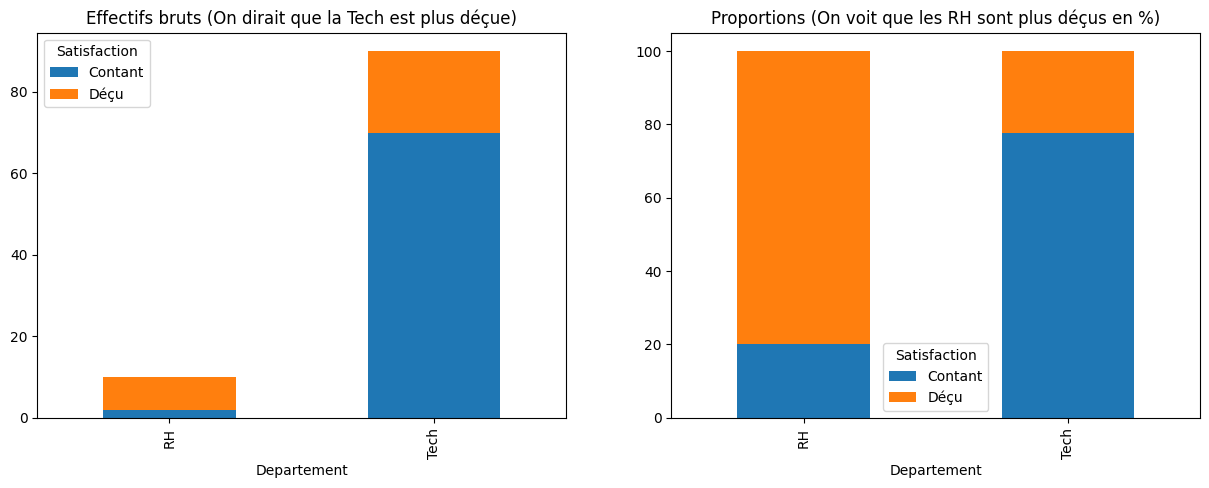

In [18]:
# 🛠️ Visualisation Python : Le passage au "Stacked Bar Chart"
# Pour visualiser une table de contingence de manière intelligente, on utilise souvent le graphique à barres empilées à 100%. C'est le seul moyen de comparer des groupes de tailles différentes.

# Données déséquilibrées (Beaucoup de Tech, peu de RH)
data = {
    'Departement': ['Tech']*90 + ['RH']*10,
    'Satisfaction': ['Contant']*70 + ['Déçu']*20 + ['Contant']*2 + ['Déçu']*8
}
df_audit = pd.DataFrame(data)

# 1. Visualisation : On compare les deux
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 2. Table de contingence brute (Counts)
brut = pd.crosstab(df_audit['Departement'], df_audit['Satisfaction'])
print("Tableau des effectifs bruts :")
print(brut)

# Graphique des effectifs (trompeur)
brut.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_title("Effectifs bruts (On dirait que la Tech est plus déçue)")

# 3. Table de contingence normalisée (Pourcentages par ligne)
normalise = round(pd.crosstab(df_audit['Departement'], df_audit['Satisfaction'], normalize='index')*100, 2)
print("Tableau des pourcentages normalisés :")
print(normalise)

# Graphique des pourcentages (la vérité)
normalise.plot(kind='bar', stacked=True, ax=ax2)
ax2.set_title("Proportions (On voit que les RH sont plus déçus en %)")

plt.show()

Conclusion : En analyse bivariée catégorielle, ne jamais conclure sans avoir normalisé ses données.

---

### Relation numérique-catégorielle : Comparaison de groupes

Le point de départ : "Imaginez que vous comparez deux livreurs de pizza. Les deux affichent une moyenne de 30 minutes. Sont-ils identiques pour autant ?"

Scénario : La bataille des livreurs

- Livreur A : Est très régulier (toujours entre 28 et 32 min).
- Livreur B : Est imprévisible (parfois 10 min, parfois 50 min).

Questions à poser aux élèves :

- La limite de la moyenne : "Si la moyenne est la même, quel indicateur vu au début du cours nous permet de dire que le Livreur A est plus 'fiable' ?" (Réponse : L'écart-type ou le CV).
- La superposition : "Si on dessine les deux cloches de Gauss l'une sur l'autre, à quoi verrait-on que les comportements sont différents ?"
- L'outil visuel : "Quel graphique permet de voir à la fois la moyenne, les quartiles et les valeurs extrêmes (outliers) pour chaque livreur sur un seul écran ?"

L'objectif : Faire comprendre que comparer des groupes, c'est comparer des distributions. L'outil roi ici est le Boxplot (Boîte à moustaches).

Statistiques par livreur :
              count       mean        std        min        25%        50%  \
Livreur                                                                      
Agile          50.0  30.093491   1.932832  25.587162  28.741646  30.025358   
Imprévisible   50.0  31.958198  11.083344  12.618884  23.635858  30.882363   

                    75%        max  
Livreur                             
Agile         31.293161  33.902284  
Imprévisible  40.428694  57.659796  


/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_56981/1628921471.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Livreur', y='Temps', data=df_pizza, palette="Set2")


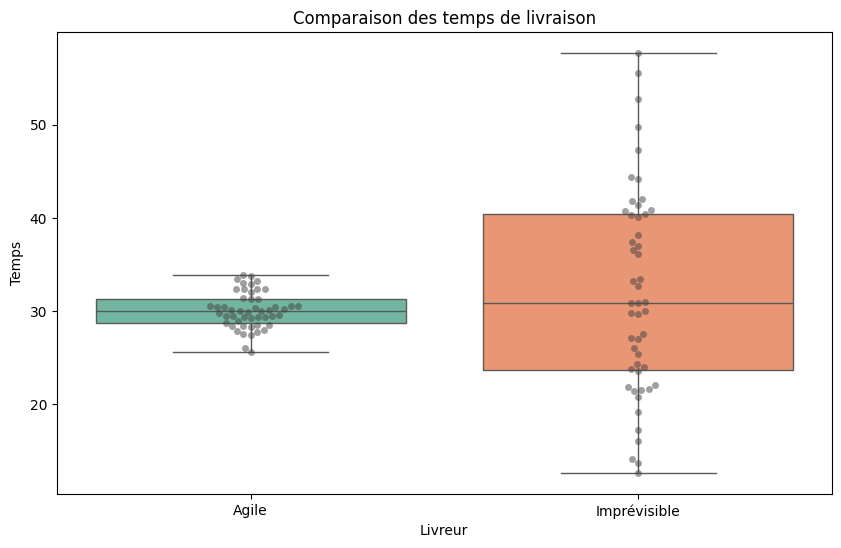

In [ ]:
# 🛠️ Visualisation Python : Le Boxplot (L'outil ultime)
# En Python, on utilise sns.boxplot en passant la variable catégorielle en X et la numérique en Y.

# Simulation de données
data = {
    'Livreur': ['Agile']*50 + ['Imprévisible']*50,
    'Temps': np.concatenate([
        np.random.normal(30, 2, 50),  # Agile : Moyenne 30, Écart-type 2
        np.random.normal(30, 10, 50)  # Imprévisible : Moyenne 30, Écart-type 10
    ])
}
df_pizza = pd.DataFrame(data)

# 1. Analyse descriptive par groupe
print("Statistiques par livreur :")
print(df_pizza.groupby('Livreur')['Temps'].describe())

# 2. Visualisation
plt.figure(figsize=(10, 6))
sns.boxplot(x='Livreur', y='Temps', data=df_pizza, palette="Set2")
sns.swarmplot(x='Livreur', y='Temps', data=df_pizza, color=".25", alpha=0.5) # Optionnel: pour voir les points
# chaque point est une vraie livraison.

plt.title("Comparaison des temps de livraison")
plt.show()

# Si vous voyez des points perdus tout seuls, ce sont des erreurs ou des records (Outliers). 
# Si vous voyez un nuage de points sur toute la boîte, ce sont toutes vos données qu'on a décidé d'afficher pour être le plus transparent possible.

In [ ]:
# Statistiques par groupe
df.groupby('region')['revenus'].describe()

# Moyenne par segment
df.groupby('segment')['montant_achat'].mean()

# Boxplot comparatif (code, la visualisation au Chapitre 8)
import matplotlib.pyplot as plt
df.boxplot(column='revenus', by='region')

---

### 🤖 IA : Interpréter des corrélations

**Prompt efficace :**

```
J'ai une matrice de corrélation avec ces valeurs significatives :
- age / revenus : 0.65
- ancienneté / satisfaction : 0.42
- heures_travail / satisfaction : -0.38
- age / ancienneté : 0.78

Contexte : Données RH d'une entreprise de 500 employés

1. Interprète chaque corrélation en termes business
2. Identifie les corrélations qui pourraient être dues à des facteurs confondants
3. Suggère des analyses complémentaires pour mieux comprendre ces relations
```

---

### ✍️ Exercice 7.3 : Analyse bivariée complète (20 min)

In [19]:
import pandas as pd
import numpy as np

# Données clients
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'client_id': range(n),
    'age': np.random.randint(18, 70, n),
    'segment': np.random.choice(['Bronze', 'Silver', 'Gold'], n, p=[0.6, 0.3, 0.1]),
    'anciennete_mois': np.random.randint(1, 60, n),
    'nb_achats': np.random.randint(1, 50, n),
    'montant_total': None  # À calculer
})

# Le montant dépend du segment et de l'ancienneté
df['montant_total'] = (
    df['nb_achats'] * 50 +
    df['anciennete_mois'] * 10 +
    df['segment'].map({'Bronze': 0, 'Silver': 500, 'Gold': 2000}) +
    np.random.normal(0, 200, n)
).clip(0)

# ANALYSE BIVARIÉE

# 1. Corrélation entre ancienneté et montant total
corr = df['anciennete_mois'].corr(df['montant_total'])
print(f"Corrélation ancienneté-montant : {corr:.2f}")

# 2. Montant moyen par segment
print("\nMontant moyen par segment :")
print(df.groupby('segment')['montant_total'].mean().round(0))

# 3. Y a-t-il un lien entre l'âge et le segment ?
contingence = pd.crosstab(
    pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['Jeune', 'Adulte', 'Senior']),
    df['segment']
)
print("\nÂge vs Segment :")
print(contingence)

# 4. Interprétation
# a) Les clients Gold dépensent-ils plus ? _____
# b) L'ancienneté est-elle corrélée aux dépenses ? _____
# c) Les seniors sont-ils plus représentés chez les Gold ? _____

Corrélation ancienneté-montant : 0.21

Montant moyen par segment :
segment
Bronze    1581.0
Gold      3609.0
Silver    2083.0
Name: montant_total, dtype: float64

Âge vs Segment :
segment  Bronze  Gold  Silver
age                          
Jeune       147    21      70
Adulte      240    42     117
Senior      210    32     121
